In [2]:
import numpy as np
import json
from tqdm import tqdm
import polars as pl
from matplotlib import pyplot as plt

In [3]:
import numpy as np
import math
import cv2
import matplotlib.pyplot as plt
import unittest

# --- The Function Under Test ---
def get_relative_rotation(H):
    """
    Returns the angle (degrees) of the source image relative to the reference.
    Positive = Clockwise rotation of Source.
    """
    # math.atan2(y, x) returns angle in radians
    # H[1,0] = sin component, H[0,0] = cos component
    transform_angle_rad = math.atan2(H[1, 0], H[0, 0])
    transform_angle_deg = math.degrees(transform_angle_rad)
    
    # Invert sign because H is the transform Source -> Reference
    return -transform_angle_deg

# --- Helper to generate synthetic H matrices ---
def create_h(rotation_deg, scale_x=1.0, scale_y=1.0, tx=0, ty=0):
    # H rotates by NEGATIVE rotation_deg to correct the image
    rad = math.radians(-rotation_deg)
    c, s = math.cos(rad), math.sin(rad)
    
    # Affine matrix
    return np.array([
        [scale_x * c, -scale_y * s, tx],
        [scale_x * s,  scale_y * c, ty],
        [0.0,          0.0,         1.0]
    ])

In [4]:
class TestHomographyExtended(unittest.TestCase):
    
    def test_cardinal_directions(self):
        """Test standard 90 degree increments"""
        test_cases = [
            (0, 0),
            (90, 90),
            (180, 180),
            (-90, -90),
            (270, -90) # 270 is equivalent to -90
        ]
        for input_deg, expected in test_cases:
            H = create_h(input_deg)
            res = get_relative_rotation(H)
            
            # Normalize result to (-180, 180] for comparison if needed
            if res > 180: res -= 360
            if res <= -180: res += 360
            
            self.assertAlmostEqual(res, expected, places=4, 
                                   msg=f"Failed on {input_deg} deg")

    def test_precision_angles(self):
        """Test small and specific angles"""
        angles = [0.1, -0.1, 45.5, -135.25]
        for ang in angles:
            H = create_h(ang)
            self.assertAlmostEqual(get_relative_rotation(H), ang, places=4)

    def test_invariance_to_translation(self):
        """Moving the image shouldn't change the rotation value"""
        H = create_h(45, tx=9999, ty=-500)
        self.assertAlmostEqual(get_relative_rotation(H), 45.0, places=4)

    def test_invariance_to_uniform_scale(self):
        """Zooming (scaling) shouldn't change rotation value"""
        H = create_h(30, scale_x=5.0, scale_y=5.0)
        self.assertAlmostEqual(get_relative_rotation(H), 30.0, places=4)

    def test_shear_resistance(self):
        """
        If aspect ratio changes (non-uniform scale), atan2(y, x) 
        might drift if we only look at col 0. 
        Note: This function assumes isotropic scaling or that col 0 represents 
        the primary orientation vector.
        """
        # Scale X by 2, Scale Y by 1
        H = create_h(45, scale_x=2.0, scale_y=1.0)
        
        # In non-uniform scaling, the angle calculation is technically 
        # valid for the X-axis vector. 
        self.assertAlmostEqual(get_relative_rotation(H), 45.0, places=4)

# Run tests
unittest.main(argv=['ignored'], verbosity=2, exit=False)

test_cardinal_directions (__main__.TestHomographyExtended.test_cardinal_directions)
Test standard 90 degree increments ... ok
test_invariance_to_translation (__main__.TestHomographyExtended.test_invariance_to_translation)
Moving the image shouldn't change the rotation value ... ok
test_invariance_to_uniform_scale (__main__.TestHomographyExtended.test_invariance_to_uniform_scale)
Zooming (scaling) shouldn't change rotation value ... ok
test_precision_angles (__main__.TestHomographyExtended.test_precision_angles)
Test small and specific angles ... ok
test_shear_resistance (__main__.TestHomographyExtended.test_shear_resistance)
If aspect ratio changes (non-uniform scale), atan2(y, x) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.003s

OK


Top Row: The simulated Source Image (rotated).
Bottom Row: The angle your function calculated from the H matrix.


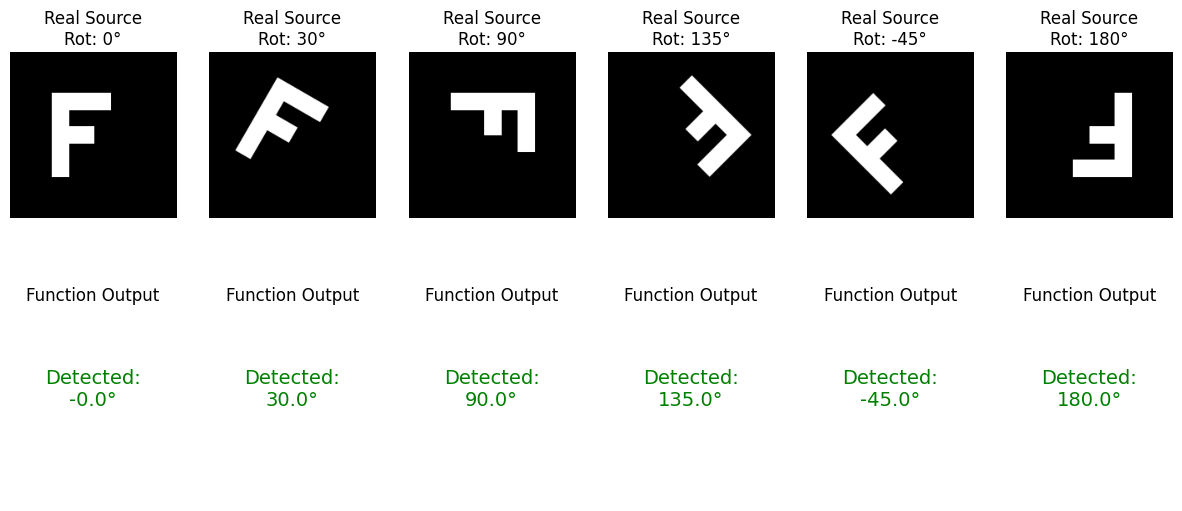

In [5]:
# Define test angles
angles_to_test = [0, 30, 90, 135, -45, 180]
num_tests = len(angles_to_test)

# Create a dummy "F" shape image (asymmetric so we can see orientation)
base_img = np.zeros((200, 200, 3), dtype=np.uint8)
# Draw an 'F'
cv2.rectangle(base_img, (50, 50), (70, 150), (255, 255, 255), -1) # Vertical
cv2.rectangle(base_img, (50, 50), (120, 70), (255, 255, 255), -1) # Top
cv2.rectangle(base_img, (50, 90), (100, 110), (255, 255, 255), -1) # Mid

# Setup Plot
fig, axes = plt.subplots(2, num_tests, figsize=(15, 6))
plt.subplots_adjust(hspace=0.4)

for i, angle in enumerate(angles_to_test):
    # 1. Create H matrix for this angle
    # We add translation (100,100) to keep the F inside the view during rotation logic
    # (Simplified for visual warping)
    H_center = create_h(angle, tx=0, ty=0)
    
    # 2. To actually warp the image visually, we need a rotation matrix around CENTER
    # The 'create_h' helper makes a matrix around (0,0). 
    # Let's just use OpenCV to visualize what the "Source" looks like rotated by 'angle'
    M_vis = cv2.getRotationMatrix2D((100, 100), -angle, 1.0) # -angle because cv2 rotates CCW
    src_visual = cv2.warpAffine(base_img, M_vis, (200, 200))

    # 3. Calculate Angle using YOUR function on the H matrix
    calculated = get_relative_rotation(H_center)
    
    # 4. Plot Source (Visual representation of the input)
    axes[0, i].imshow(src_visual)
    axes[0, i].set_title(f"Real Source\nRot: {angle}°")
    axes[0, i].axis('off')
    
    # 5. Plot "Recovered" (Reference view)
    # We warp the 'src_visual' using H_center. 
    # Since H_center rotates by -angle, it should straighten the image back up.
    # Note: We need a slight adjustment because H_center is around (0,0) not (100,100)
    # but for checking the NUMBER output, this is fine.
    
    color = "green" if abs(calculated - angle) < 0.1 else "red"
    
    # Just show a text placeholder for the calculation result
    axes[1, i].text(0.5, 0.5, f"Detected:\n{calculated:.1f}°", 
                    fontsize=14, ha='center', color=color,
                    transform=axes[1, i].transAxes)
    axes[1, i].set_title("Function Output")
    axes[1, i].axis('off')

print("Top Row: The simulated Source Image (rotated).")
print("Bottom Row: The angle your function calculated from the H matrix.")
plt.show()

In [9]:
df = pl.read_csv('/home/dangnh36/datasets/ecg/processed/keypoints_by_round2.csv').with_row_index('index')
df

index,id,type_id,rot_code,H,keypoints
u32,i64,i64,i64,str,str
0,1449491391,1,null,null,"""{'g_0_1': array([39.37007874, …"
1,1449491391,3,null,"""[[1.0495655422639434, 0.001866…","""{'g_0_1': array([71.30957031, …"
2,1449491391,4,null,"""[[1.046684077895563, -0.007838…","""{'g_0_1': array([61.88232422, …"
3,1449491391,5,null,"""[[0.7933523312631544, 0.069650…","""{'g_0_1': array([627.046875 ,…"
4,1449491391,6,null,"""[[0.8145082231514592, 0.009951…","""{'g_0_1': array([ 172.85154724…"
…,…,…,…,…,…
8788,3817987033,6,null,"""[[0.6941040222028352, 0.042332…","""{'g_0_1': array([424.8046875 ,…"
8789,3817987033,9,null,"""[[0.6794530911014078, -0.00383…","""{'g_0_1': array([532.546875 ,…"
8790,3817987033,10,null,"""[[0.5704590543488949, -0.00507…","""{'g_0_1': array([197.859375 ,…"


In [10]:
df = df.with_columns(
    pl.col('H').map_elements(lambda x: get_relative_rotation(np.array(eval(x))), return_dtype=pl.Float32).alias('angle')
)
df

index,id,type_id,rot_code,H,keypoints,angle
u32,i64,i64,i64,str,str,f32
0,1449491391,1,null,null,"""{'g_0_1': array([39.37007874, …",null
1,1449491391,3,null,"""[[1.0495655422639434, 0.001866…","""{'g_0_1': array([71.30957031, …",0.077927
2,1449491391,4,null,"""[[1.046684077895563, -0.007838…","""{'g_0_1': array([61.88232422, …",-0.270805
3,1449491391,5,null,"""[[0.7933523312631544, 0.069650…","""{'g_0_1': array([627.046875 ,…",0.712103
4,1449491391,6,null,"""[[0.8145082231514592, 0.009951…","""{'g_0_1': array([ 172.85154724…",-0.134646
…,…,…,…,…,…,…
8788,3817987033,6,null,"""[[0.6941040222028352, 0.042332…","""{'g_0_1': array([424.8046875 ,…",-0.4031
8789,3817987033,9,null,"""[[0.6794530911014078, -0.00383…","""{'g_0_1': array([532.546875 ,…",-0.839226
8790,3817987033,10,null,"""[[0.5704590543488949, -0.00507…","""{'g_0_1': array([197.859375 ,…",-0.08152


(array([2.000e+00, 2.000e+00, 6.000e+00, 7.000e+00, 9.000e+00, 1.200e+01,
        2.500e+01, 4.000e+01, 5.900e+01, 1.010e+02, 1.440e+02, 2.000e+02,
        2.950e+02, 4.680e+02, 7.780e+02, 8.410e+02, 8.870e+02, 1.011e+03,
        1.094e+03, 5.440e+02, 3.630e+02, 2.900e+02, 1.720e+02, 1.470e+02,
        9.200e+01, 6.600e+01, 3.400e+01, 3.300e+01, 2.600e+01, 1.400e+01,
        1.500e+01, 7.000e+00, 9.000e+00, 6.000e+00, 6.000e+00, 3.000e+00,
        4.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([-3.46767735, -3.27246356, -3.07724977, -2.88203573, -2.68682194,
        -2.49160814, -2.29639435, -2.10118032, -1.90596652, -1.71075273,
        -1.51553893, -1.32032502, -1.12511122, -0.92989737, -0.73468351,
        -0.53946966, -0.34425581, -0.14904195,  0.04617189,  0.24138574,
         0.43659958,  0.63181341,  0.82702726,  1.02224112,  1.21745503,
         1.

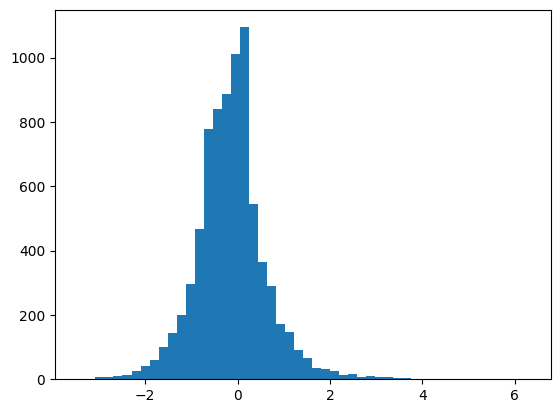

In [14]:
plt.hist(df['angle'], bins = 50)